# Week 03 — Linear Regression

## Business Problem

We work for the university, who have a dataset of info about student grades.  This dataset contains potentially useful data that could help predict grades.  The university want us to look at this data set and to build a linear regression model that will use historical data to predict student grades.


In [3]:
# import packages

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sweetviz as sv

In [2]:
# read in data
filename = 'grades_multi_1000.csv'
df = pd.read_csv("../data/" + filename)

## EDA

Before building a model, we first need to understand the data we have.  Let's perform some basic EDA.

In [4]:
# get the shape of the data
df.shape

(1000, 5)

In [ ]:
# get info on variables
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Hours_Studied          1000 non-null   int64  
 1   Hours_Sleep            1000 non-null   int64  
 2   Number_of_Assignments  1000 non-null   int64  
 3   Dist_from_College      1000 non-null   float64
 4   Grade                  1000 non-null   int64  
dtypes: float64(1), int64(4)
memory usage: 39.2 KB


In [6]:
# get some basic stats on those variables
df.describe()

,Hours_Studied,Hours_Sleep,Number_of_Assignments,Dist_from_College,Grade
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,240.028000,8.027000,16.328000,4.943230,65.144000
std,106.278438,2.191135,5.837679,5.463257,21.000626
min,75.000000,4.000000,4.000000,0.000000,30.000000
25%,158.000000,6.000000,12.000000,0.980000,47.000000
50%,220.000000,8.000000,16.000000,3.045000,65.000000
75%,305.000000,9.000000,21.000000,7.180000,84.000000
max,500.000000,14.000000,31.000000,40.050000,100.000000


In [7]:
# let's have a look at a few lines of data
df.head()

,Hours_Studied,Hours_Sleep,Number_of_Assignments,Dist_from_College,Grade
0,110,7,10,17.92,33
1,205,9,18,0.30,82
2,108,6,13,8.37,43
3,485,12,30,4.98,97
4,390,9,19,1.03,78


In [31]:
# create sweetviz report to automate EDA
sv_report = sv.analyze(df)
sv_report.show_html() 

                                             |          | [  0%]   00:00 -> (? left)

Report SWEETVIZ_REPORT.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


In [ ]:
# sweetviz tells us there are duplicate rows, but this doesn't seem to be the case when we look at the data!  Weird!
df_duplicates = df.duplicated()
df[df_duplicates]

,Hours_Studied,Hours_Sleep,Number_of_Assignments,Dist_from_College,Grade
781,205,5,6,0.0,41
794,203,8,16,0.0,61


OK, so we don't have an enormous amount of data (just 1k rows).  But we have a selection of numeric variables that could potentially be useful.  Some key findings from EDA:

* All fields seem to have a value (no missing values found)
* Each row apepars to be an individual student
* All fields are numeric
* Grade seems to be relatively uniformly distributed, suggesting we have a good spread of results (i.e. not eveyone is high performing)

## Prepare data for modelling

Another step to perform ahead of modelling is preparing our data for use.  We wouldn't want to build a model using all our data for two key reasons:

1. We wouldn't have any data left that we could use to test our model's accuracy
1. We would be creating a model that would have seen the 'grade' of each student - this data leakage would effectively mean that our model had access to data that it wouldn't have for new data, and would be 'overfit'

To avoid this, we need to split our data into train and test sets.  We also need to remove the 'grade' variable from the test set.

In [11]:
from sklearn.model_selection import train_test_split

df_train, df_test = train_test_split(df, test_size=0.25, random_state=42)

In [12]:
# let's have a look at the train data
df_train.head()

,Hours_Studied,Hours_Sleep,Number_of_Assignments,Dist_from_College,Grade
82,320,12,26,0.18,96
991,265,6,11,6.42,53
789,133,7,10,8.25,40
894,130,5,14,0.77,52
398,120,7,12,14.58,36


In [13]:
print(df.shape)
print(df_train.shape)
print(df_test.shape)

(1000, 5)
(750, 5)
(250, 5)


Before continuing, let's calculate some basic correlation of our variables.  Any predictor variables that are highly correlated with other predicators (i.e. above 0.8) might adversely impact our model and would need to be removed.

In [14]:
df_train.corr(numeric_only=True)

,Hours_Studied,Hours_Sleep,Number_of_Assignments,Dist_from_College,Grade
Hours_Studied,1.000000,0.553509,0.651632,-0.280284,0.733354
Hours_Sleep,0.553509,1.000000,0.718656,-0.287155,0.783640
Number_of_Assignments,0.651632,0.718656,1.000000,-0.316631,0.898631
Dist_from_College,-0.280284,-0.287155,-0.316631,1.000000,-0.369514
Grade,0.733354,0.783640,0.898631,-0.369514,1.000000


Here we can see that number of hours slept and number of assignments are strongly correlated, but not so much that is would cause too much concern.  

Let's visualise this:

<Axes: >

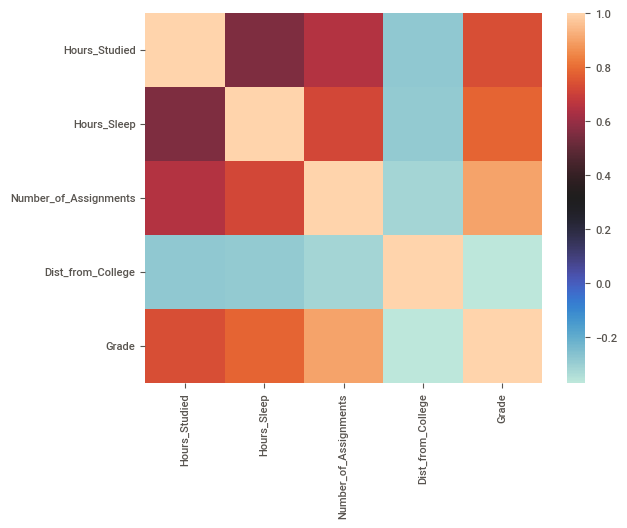

In [23]:
sns.heatmap(df_train.corr(), cmap='icefire')

The colour palette for this visual has been carefully selected to demonstrate how there are both positive and negative correlations in the data.  'Dist_from_College' has a negatively correlated relationship with all the other variables (including the target 'grade').

So far we have read in our data, checked for duplicated/missing data, split into train and test sets, and done some EDA that has revealed some things about our data.  Now we need to prepare it for modelling - we **do not** want to give our model the 'grade' column as this will mean giving it access to data that will not exist when shown new data...



In [25]:
# We need to separate target (y) from the input variables X

x_train = df_train.drop('Grade', axis=1)
x_test = df_test.drop('Grade', axis=1)

# create objects to hold our grade variable so they aren't lost and can be used later
y_train = df_train['Grade']
y_test = df_test['Grade']

In [27]:
# quick check of the number of rows and cols in our dataframes:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(750, 4)
(250, 4)
(750,)
(250,)


## Assumptions

We've chosen to use a linear regression model for this problem.  There are a number of assumptions we are making that will need to be validated:

* linearity - is there a linear relationship between the response (grade) and each of the predictors?
* each observation in the data is inpdependent (e.g. not the same students measured repeatedly)
* homoscedacity - https://www.statology.org/concise-guide-homoscedasticity/ - consistent variance in each predictor 
* normally distributed residuals


### Homoscedacity notes

This is the need for consistent variance in each of the predictor variables.  If low, the model's ability to provide consistent accurate predictions is impeded.

For example, when analysing people's wages we may observe that variance of salary may be relatively consistent for those with low incomes, with most low-income workers earning somewhere between £25k-£35kpa.  But we would also likely observe that income variance would increase for those with higher salaries as some workers might earn much more than others - e.g. £60k-£120k.

If we were to plot this data on a scatter plot the resulting cloud of data would look like a funnel, which would signal that this predictor variable has low homoscedacity.  If the data had high homoscedacity the scatter plot would look more like a line - it would have consistent variance (spread) and would be straight (linear - not wavy).


We must test these assumptions as we go.

## Building the model

We're ready to start training our linear regression model.  To do this, we give the model two training datasets:
1. the data we wish the model to use without the target variable, which in this case is all our student data (excluding the grade variable) 
1. a separate dataset containing the target variable we want it to predict, which in this case is the 'grade'  

We do not include the target variable in the main training data as this would give the model access to data it won't see when new data comes in.  Doing this is called 'leakage', and doing it would mean our model would be incredibly accurate durign testing but would likely suffer worse performance during testing and live use.

In [30]:
# import the model we wish to use
from sklearn.linear_model import LinearRegression 

# create an instance of the model that we can use
model = LinearRegression()

# fit the model using our data
model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[ 0.04, 2.27, 2.06,-0.24]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['Hours_Studied','Hours_Sleep','Number_of_Assignments','Dist_from_College']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4.172
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,4


Lots going on here... we have:
* imported the LinearRegression class from the scikit-learn package (ignore naming this time, it's a quirk of this package)
* created an instance of that class - this means we have creted an object that belongs to that class (more below).  
* used the 'fit' method of the LinearRegression class to train a linear regression model using our input data

Objects of a given class will have 'methods', which are functions that belong to that class.  Here, the 'fit' method is a function that LinearRegression class - it is only accessible via the 'model' object we created to hold an instance of the LinearRegression class.

Let's use our model to make some predictions:


In [ ]:
y_pred = model.predict(X_test)

# produces a numpy array containing predicted values - let's look at the first 10 predictions
y_pred[0:10]

array([104.20777678,  58.3719758 ,  73.44407433,  62.99656941,
        44.01053893,  40.28220411,  80.88463821,  77.11470336,
        49.96678062,  68.91686371])

Great, that seems to have worked.

## Model Evaluation

We need to assess how well our model has made those predictions - this is known as model performance.

There are a few metrics that help us understand model performance:
* r-squared (r2) - how much variation in grades is explained by our model
* mean absolute error (mae) - average prediction error (in target variable points - here 'grade')
* root mean square error (rmse) - similar to mae but punishes large errors more (good for spotting large errors)

These functions help assess the error element of our linear equation, and they help us understand the scale of those errors and their impact on model accuracy.

### R-squared

R2 is a measure of how much of the variance in the dependent variable is explained by the independent variable - a high r2 tells us there is little variation (accurate model), where a low r2 tells us there is a high degree of variation (less accurate).  We can think of r2 as a measure of how well our model captures the story in the data, and how much of it is left as unexplained noise.

Therre are several ways to calculate it but the basic calculation is $ r^2 = 1 - RSS / TSS $

* RSS is the Residual Sum of Squares - the sum of all the squared differences between predictions and actual values
* TSS is the Total Sum of Squares - the sum of all the squared differences between actual values and the mean

This means that r2 is the fraction of the total variation that the model accounts for (if you take away error what is left is down tot he model).

For this reason the value of r2 lies between 0 and 1:
* 0 - the model explains none of the variance in the dependent variable
* 1 - the model explains all of the variance in the dependent variable

R2 explains the relationship between a single independent variable and the dependent variable.  If more than one independent variable is added, r2 will increase (but never decrease).  For this reason, adjusted r2 is a better measure - this includes the number of predictor variables in the calculation, effectively penalising the score for using unnecessary predictors.

High r2 is not always a good thing - it could indicate that the model is overfitting.

### MAE vs RMSE

The mae and rmse values are quite similar in that they both give us a metric that helps us understand how accurate our predictions are.  Both of these measures are in the same unit as the response variable and tell us, on average, the scale of the error.

There is a key difference between mae and rmse - rmse 'punishes' larger errors more than mae.  To understand this consider the core question we are asking: when the model prediction is wrong, how harshly should the penalty scale with the size of the mistake?  i.e. should a large error have a large impact on our understanding of accuracy?  

MAE is quite robust to outliers, meaning larger errors do not have a large impact on the measure of accuracy - this can make larger errors seem like less of a promblem.  Conversely, RMSE squares it's values meaning larger losses are magnified - the bigger the loss the more the magnification.  This makes it useful for identifying if the model is making larger errors.

In [43]:
# import useful functions
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R2:  ", r2)
print("MAE: ", mae)
print("RMSE: ", rmse)

R2:   0.8696219399558631
MAE:  5.888975168130661
RMSE:  7.484216298533014


What do these scores mean?

R2 = around 87% of the variance in grades is explained by our model.  This is a high score - we wouldn't normally expect scores this high in real world data
MAE = our model predictions are off by around 5.9 grade points, which isn't bad
RMSE = taking into account a few larger errors in our predictions, our model is around 7.48 grade points off which is also not bad


### Plot Residuals


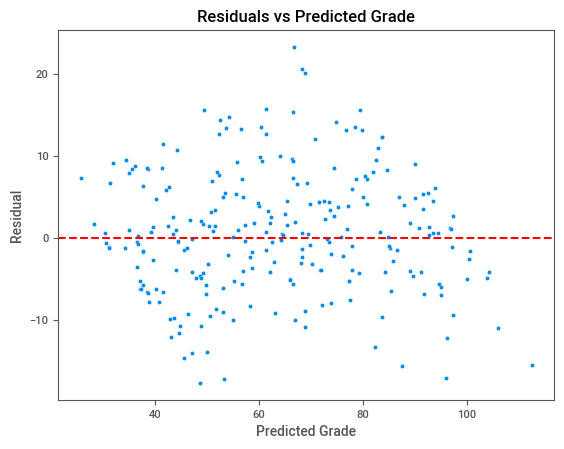

In [ ]:
residuals = y_test - y_pred

#sns.residplot(x=y_pred, y=residuals)

sns.scatterplot(x=y_pred, y=residuals)
plt.xlabel('Predicted Grade')
plt.ylabel('Residual')
plt.title('Residuals vs Predicted Grade')
plt.axhline(y=0, color='red', linestyle='--')

This random cloud is good because the model has already explained all the patterns it can find - this is a plot of the parts of the actual grade scores that we can't predict.



## Validate Assumptions 

### Linearity

To test this assumption we must plot each predictor variable against grade.

In [ ]:
sns.scatterplot(data=df, x='Hours_Studied', y='Grade')

### Normally distributed residuals

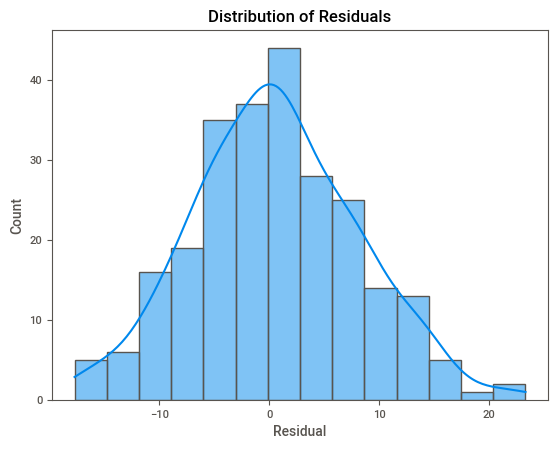

In [48]:
sns.histplot(residuals, kde=True)

plt.xlabel('Residual')
plt.title('Distribution of Residuals')

plt.show()

# TO DO

* Validate assumptions
* Evaluate the model
